In [2]:
import mooring_lib as ml
import numpy as np
import sympy as sp 
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

print('import done')

import done


In [3]:
T_minus, spatial_vars = ml.symbolic_tension_vector_expression_minus()
T_plus, spatial_vars = ml.symbolic_tension_vector_expression_plus()
T_total, spatial_vars = ml.symbolic_tension_vector_total()

T_minus_norm = sp.sqrt(T_minus[0]**2 + T_minus[1]**2)
T_plus_norm = sp.sqrt(T_plus[0]**2 + T_plus[1]**2)
T_total_norm = sp.sqrt(T_total[0]**2 + T_total[1]**2)

In [4]:
d=100
d0=40
theta = np.pi / 4
An = 4*0.1**2 * np.pi / 4
E = 10e9

variable_dict = {
    'd' : d,
    'd_0' : d0,
    'theta_0': theta,
    'A_N' : An,
    'E' : E
}

f_T = sp.lambdify(spatial_vars, T_plus[1].subs(variable_dict), modules='numpy')



In [5]:
def plot(f, ax,scale='lin', title=''):
    b0 = (d - d0) / np.tan(theta)
    y_min = -b0
    y_max = b0
    z_min = -d
    z_max = 0

    ar_y = np.linspace(y_min, y_max, 500)
    ar_z = np.linspace(z_min, z_max, 500)

    vals_Y, vals_Z = np.meshgrid(ar_y, ar_z)

    f_vals = f(vals_Y, vals_Z)
    ax.set_title(title)
    ax.set_xlim(y_min, y_max)
    ax.set_ylim(z_min, z_max)
    if scale=='lin':
        im = ax.imshow(f_vals, extent=[y_min, y_max, z_min, z_max], origin='lower', cmap='viridis')#, norm=LogNorm())
    elif scale == 'log':
        im = ax.imshow(f_vals, extent=[y_min, y_max, z_min, z_max], origin='lower', cmap='viridis', norm=LogNorm())
    ax.figure.colorbar(im, ax=ax)
    

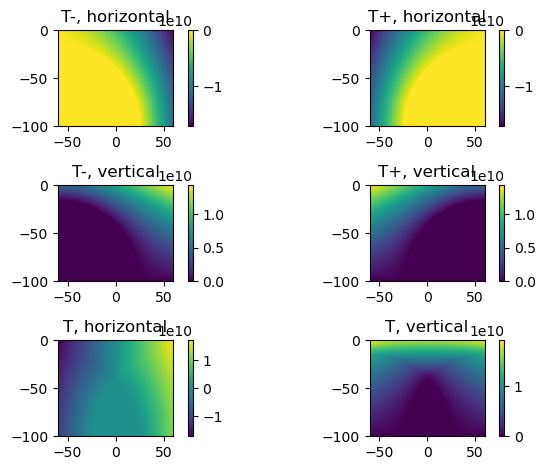

In [6]:
f_T_minus_h = sp.lambdify(spatial_vars, -1*T_minus[0].subs(variable_dict), modules='numpy')
f_T_minus_v = sp.lambdify(spatial_vars, T_minus[1].subs(variable_dict), modules='numpy')
f_T_plus_h = sp.lambdify(spatial_vars, T_plus[0].subs(variable_dict), modules='numpy')
f_T_plus_v = sp.lambdify(spatial_vars, T_plus[1].subs(variable_dict), modules='numpy')

#f_T_total_h = sp.lambdify(spatial_vars, -1*T_minus[0].subs(variable_dict) + T_plus[0].subs(variable_dict), modules='numpy')
#f_T_total_v = sp.lambdify(spatial_vars, T_minus[1].subs(variable_dict) + T_plus[1].subs(variable_dict), modules='numpy')

f_T_total_h =sp.lambdify(spatial_vars, T_total[0].subs(variable_dict), modules='numpy')
f_T_total_v =sp.lambdify(spatial_vars, T_total[1].subs(variable_dict), modules='numpy')

fig, axs = plt.subplots(3,2)
plot(f_T_minus_h, axs[0,0], title='T-, horizontal')
plot(f_T_minus_v, axs[1,0], title='T-, vertical')
plot(f_T_plus_h, axs[0,1], title='T+, horizontal')
plot(f_T_plus_v, axs[1,1], title='T+, vertical')
plot(f_T_total_h, axs[2,0], title='T, horizontal')
plot(f_T_total_v, axs[2,1], title='T, vertical')
plt.tight_layout()


AttributeError: 'Axes' object has no attribute 'xlabel'

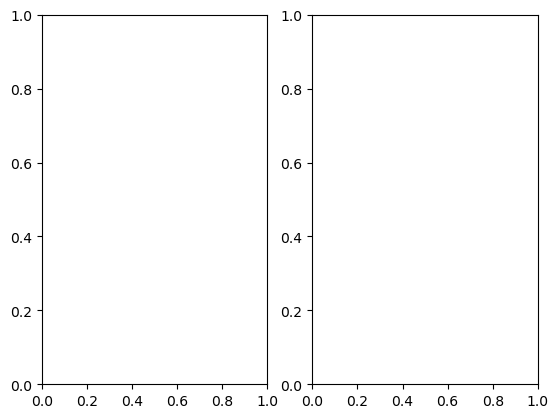

In [ ]:
def dirac_delta(x):
    if x==0:
        return np.inf
    else:
        return 0

dirac_delta_vec = np.vectorize(dirac_delta)

K_total = ml.symbolic_stifness_matrix_total()

k_yy = K_total[0,0]
k_zz = K_total[1,1]
f_k_yy = sp.lambdify(spatial_vars, k_yy.subs(variable_dict), modules=[{'DiracDelta' : dirac_delta_vec}, 'numpy'])
f_k_zz = sp.lambdify(spatial_vars, k_zz.subs(variable_dict), modules=[{'DiracDelta' : dirac_delta_vec}, 'numpy'])

fig, axs = plt.subplots(1,2)
axs[0].x_label('y [m]')
axs[0].xlabel('z [m]')

plot(f_k_yy, axs[0], title='k_yy', scale='log')
plot(f_k_zz, axs[1], title='k_zz', scale='log')
plt.tight_layout()


In [8]:
#f_k_zz(0, -10)
f_k_yy(0, -10)

np.float64(287084494.7422735)

In [9]:
f_T_total_v(0, -10)

np.float64(12188243087.777235)

In [10]:
K_total

Matrix([
[A_N*E*(-y - (d - d_0)*cot(theta_0))*(y + (d - d_0)*cot(theta_0))*(-(d - d_0)/sin(theta_0) + sqrt((d + z)**2 + (y + (d - d_0)*cot(theta_0))**2))*Heaviside(-(d - d_0)/sin(theta_0) + sqrt((d + z)**2 + (y + (d - d_0)*cot(theta_0))**2))/((d + z)**2 + (y + (d - d_0)*cot(theta_0))**2)**(3/2) + A_N*E*(-y + (d - d_0)*cot(theta_0))*(y - (d - d_0)*cot(theta_0))*(-(d - d_0)/sin(theta_0) + sqrt((d + z)**2 + (-y + (d - d_0)*cot(theta_0))**2))*Heaviside(-(d - d_0)/sin(theta_0) + sqrt((d + z)**2 + (-y + (d - d_0)*cot(theta_0))**2))/((d + z)**2 + (-y + (d - d_0)*cot(theta_0))**2)**(3/2) + A_N*E*(y - (d - d_0)*cot(theta_0))**2*(-(d - d_0)/sin(theta_0) + sqrt((d + z)**2 + (-y + (d - d_0)*cot(theta_0))**2))*DiracDelta(-(d - d_0)/sin(theta_0) + sqrt((d + z)**2 + (-y + (d - d_0)*cot(theta_0))**2))/((d + z)**2 + (-y + (d - d_0)*cot(theta_0))**2) + A_N*E*(y - (d - d_0)*cot(theta_0))**2*Heaviside(-(d - d_0)/sin(theta_0) + sqrt((d + z)**2 + (-y + (d - d_0)*cot(theta_0))**2))/((d + z)**2 + (-y + (d - d

In [11]:
f_K_total = sp.lambdify(spatial_vars, K_total.subs(variable_dict), modules=[{'DiracDelta' : dirac_delta_vec}, 'numpy'])

In [12]:
f_K_total(0, -29)

array([[2.93725565e+08, 0.00000000e+00],
       [0.00000000e+00, 3.89370965e+08]])

In [13]:
def get_K(x0, y0, z0, u, w, d0, d, theta):
    ar = np.array([[4.05103482e+08, 0.00000000e+00],
       [0.00000000e+00, 6.10606565e+08]])
    return ar

In [14]:
# get stiffess at location

K_m = get_K

